In this notebook, we use the 3.8B parameter [Phi-3 model](https://huggingface.co/microsoft/Phi-3-mini-4k-instruct) to write move reviews.

We will also take a closer look at the inputs and outputs of the tokenizer and the LLM, to understand what is happening under the hood when we call a LLM text generation API.

We also look at the effect of `temperature`, a common parameter used to control LLM text generation randomness. Higher temperature gives more random/creative outputs, while lower, near zero gives less varied outputs. There is also a "greedy" text generation strategy: under this strategy, the vocab token with the highest next token probability will always be selected, making the generation deterministic.



In [ ]:
!pip install transformers==4.41.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.4 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.52.4
    Uninstalling transformers-4.52.4:
      Successfully uninstalled transformers-4.52.4


In [ ]:
import torch
import transformers

transformers.utils.logging.set_verbosity_error()
device = 'cuda' if torch.cuda.is_available() else 'cpu'

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [ ]:
device

'cuda'

In [ ]:
# P(next_token | previous_token)

In [ ]:
#@title Download phi-3 model and its tokenizer from hugging face

from transformers import AutoModelForCausalLM, AutoTokenizer

phi3_model = AutoModelForCausalLM.from_pretrained("microsoft/Phi-3-mini-4k-instruct",
                                             torch_dtype="auto",
                                             trust_remote_code=True
                                             )

phi3_tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
# Our text generation "API".
def llm_generate_text(model, tokenizer, prompt, temperature=0.8, max_new_tokens=256, **kwargs):
  tokenized_inputs = tokenizer(prompt, return_tensors="pt")
  tokenized_inputs = {k: v.to(device) for k, v in tokenized_inputs.items()}

  model = model.to(device)

  predicted_token_ids = model.generate(
      **tokenized_inputs,
      temperature=temperature,
      max_new_tokens=max_new_tokens,
      **kwargs
  )[0]

  print(tokenizer.decode(predicted_token_ids))

### Generate movie review using phi3 model

* We ask the model to write a movie review starting with "I".
* The phi3 model expects chat formatted input. We use `tokenizer.apply_chat_template` to easily do this.

It's easy to see that phi3's movie reviews are vastly better than our previous bi-gram and 4-gram models. Importantly, we did not need to train the phi3 model either: the model has gone through sufficient prior training to satisfy our request.

In [ ]:
prompt = 'Write a movie review. The review should start with the word "I".'

messages = [{"role": "user", "content": prompt}]
phi3_prompt = phi3_tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
print(phi3_prompt)

llm_generate_text(phi3_model, phi3_tokenizer, phi3_prompt)

<|user|>
Write a movie review. The review should start with the word "I".<|end|>
<|assistant|>

<|user|> Write a movie review. The review should start with the word "I".<|end|><|assistant|> I recently watched the film "The Shawshank Redemption," and it left an indelible mark on my heart. This timeless classic, directed by Frank Darabont, is based on Stephen King's novella "Rita Hayworth and Shawshank Redemption." The story follows the life of Andy Dufresne, a banker who is wrongfully convicted of murdering his wife and her lover.

The film's strength lies in its exceptional performances, particularly by Tim Robbins as Andy and Morgan Freeman as Ellis "Red" Redding. Robbins' portrayal of Andy is both nuanced and compelling, showcasing the character's resilience and unwavering hope in the face of adversity. Freeman's portrayal of Red is equally powerful, as he embodies the character's wisdom, loyalty, and unwavering spirit.

The screenplay, written by Darabont, is a masterpiece in its ow

### Now let's look at the `llm_generate_text` function line by line.
```
def llm_generate_text(model, tokenizer, prompt, temperature=0.8, max_new_tokens=256):
  tokenized_inputs = tokenizer(prompt, return_tensors="pt")
  tokenized_inputs = {k: v.to(device) for k, v in tokenized_inputs.items()}

  model = model.to(device)

  predicted_token_ids = model.generate(
      **tokenized_inputs,
      do_sample=True,
      temperature=temperature,
      max_new_tokens=max_new_tokens,
  )[0]

  print(tokenizer.decode(predicted_token_ids))
```

In [ ]:
#@title Tokenize text input
print(f'prompt = {phi3_prompt}')
print()

print('Tokenizing the prompt......')
phi3_tokens = phi3_tokenizer(phi3_prompt, return_tensors="pt")
print(phi3_tokens)

prompt = <|user|>
Write a movie review. The review should start with the word "I".<|end|>
<|assistant|>


Tokenizing the prompt......
{'input_ids': tensor([[32010, 14350,   263, 14064,  9076, 29889,   450,  9076,   881,  1369,
           411,   278,  1734,   376, 29902,  1642, 32007, 32001]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [ ]:
#@title The LLM generates token ids
phi3_tokens = {k: v.to(device) for k, v in phi3_tokens.items()}
phi3_model = phi3_model.to(device)

predicted_phi3_token_ids = phi3_model.generate(
      **phi3_tokens,
      do_sample=True,
      temperature=0.9,
      max_new_tokens=16,
  )
predicted_phi3_token_ids

tensor([[32010, 14350,   263, 14064,  9076, 29889,   450,  9076,   881,  1369,
           411,   278,  1734,   376, 29902,  1642, 32007, 32001,   306, 10325,
           750,   278, 15377,   310, 21217,   376,  1576, 28548,   845,   804,
          4367,   331,   683,  1699]], device='cuda:0')

In [ ]:
#@title Translate generated token ids back to text
phi3_tokenizer.decode(predicted_phi3_token_ids[0])

'<|user|> Write a movie review. The review should start with the word "I".<|end|><|assistant|> I recently had the pleasure of watching "The Shawshank Redemption,"'

In [ ]:
#@title Controling text generation randomness with temperature
for _ in range(3):
  print('-------------------------------------------------------------------')
  print(f'temperature = 1e-9')
  llm_generate_text(phi3_model, phi3_tokenizer, phi3_prompt, temperature=1e-9, max_new_tokens=16)
print('###################################################################')

for _ in range(3):
  print('-------------------------------------------------------------------')
  print(f'temperature = 1.0')
  llm_generate_text(phi3_model, phi3_tokenizer, phi3_prompt, temperature=1.0, max_new_tokens=16)
print('###################################################################')

for _ in range(3):
  print('-------------------------------------------------------------------')
  print(f'temperature = 10.0')
  llm_generate_text(phi3_model, phi3_tokenizer, phi3_prompt, temperature=10.0, max_new_tokens=16)
print('###################################################################')

-------------------------------------------------------------------
temperature = 1e-9
<|user|> Write a movie review. The review should start with the word "I".<|end|><|assistant|> I recently watched the film "The Shawshank Redemption," and it
-------------------------------------------------------------------
temperature = 1e-9
<|user|> Write a movie review. The review should start with the word "I".<|end|><|assistant|> I recently watched the film "The Shawshank Redemption," and it
-------------------------------------------------------------------
temperature = 1e-9
<|user|> Write a movie review. The review should start with the word "I".<|end|><|assistant|> I recently watched the film "The Shawshank Redemption," and it
###################################################################
-------------------------------------------------------------------
temperature = 1.0
<|user|> Write a movie review. The review should start with the word "I".<|end|><|assistant|> I recently watched t

# Optional

## Decoding Strategies / Sampling

### A. Greedy Sampling

In [ ]:
print("\n--- Greedy Search ---")
print("Parameters: do_sample=False, num_beams=1 (default)")
prompt = "The capital of France is"
llm_generate_text(
    phi3_model,
    phi3_tokenizer,
    prompt,
    do_sample=False,  # Essential for greedy search
    max_new_tokens=20
)


--- Greedy Search ---
Parameters: do_sample=False, num_beams=1 (default)
The capital of France is Paris.


### Response:The capital of France is Paris.<|endoftext|>


### B. Beam Search


#### Beam Search: Mathematical Example by Hand

Let's walk through a step-by-step mathematical calculation for Beam Search.

**How it works:**
Beam search is a deterministic search algorithm that explores a fixed number of the most promising sequences (called "beams") at each step of text generation. Instead of just picking the single most probable next token (like greedy search), it keeps track of `num_beams` partial sequences. At each step, it extends *all* of these `num_beams` sequences by considering all possible next tokens, calculates the cumulative probability (score) of each new extended sequence, and then selects the overall `num_beams` best-scoring sequences to carry forward to the next step.

**Scenario:**
Our LLM has processed the prompt "The cat sat on the" and needs to predict the next **2 words**.

**Goal:** Apply Beam Search with `num_beams = 2`.

**Hypothetical Vocabulary & Probabilities:**
We'll assume the LLM outputs probabilities for a very small set of next tokens at each stage. The score of a sequence is the **product of the probabilities** of all tokens in that sequence (a real LLM would use log-probabilities for numerical stability, but product is easier to illustrate by hand).

---

#### **Initial State:**

**Input Prompt:** "The cat sat on the"
**Number of Beams (`num_beams`):** 2

---

#### **Step 1: Predicting the 1st New Word**

The LLM processes the prompt "The cat sat on the" and generates probabilities for the next token.

**Hypothetical Probabilities for the 1st New Word:**

| Token   | Probability |
| :------ | :---------- |
| mat     | 0.6         |
| floor   | 0.3         |
| chair   | 0.08        |
| table   | 0.01        |
| door    | 0.01        |

**Action:** Select the `num_beams = 2` tokens with the highest probabilities.

1.  **"mat"** (Probability: 0.6)
2.  **"floor"** (Probability: 0.3)

**Current Beams (Sequences) after Step 1:**

* **Beam 1:** "The cat sat on the **mat**" (Score: 0.6)
* **Beam 2:** "The cat sat on the **floor**" (Score: 0.3)

---

#### **Step 2: Predicting the 2nd New Word**

Now, for *each* of our current 2 beams, the LLM will predict the next word. We calculate the new cumulative score for each possible extended sequence (Current Beam Score $\times$ Probability of New Token).

---

##### **Focus on Beam 1:** "The cat sat on the **mat**" (Current Score: 0.6)

The LLM processes "The cat sat on the mat" and predicts the next token.

**Hypothetical Probabilities for the word after "mat":**

| Token   | Probability (given "mat") |
| :------ | :------------------------ |
| .       | 0.7                       |
| ,       | 0.2                       |
| with    | 0.1                       |

**Possible continuations from Beam 1:**

1.  "The cat sat on the mat **.**"
    * New Score: $0.6 \text{ (Beam 1 Score)} \times 0.7 \text{ (Prob of '.') } = \mathbf{0.42}$
2.  "The cat sat on the mat **,**"
    * New Score: $0.6 \text{ (Beam 1 Score)} \times 0.2 \text{ (Prob of ',') } = \mathbf{0.12}$
3.  "The cat sat on the mat **with**"
    * New Score: $0.6 \text{ (Beam 1 Score)} \times 0.1 \text{ (Prob of 'with') } = \mathbf{0.06}$

---

##### **Focus on Beam 2:** "The cat sat on the **floor**" (Current Score: 0.3)

The LLM processes "The cat sat on the floor" and predicts the next token.

**Hypothetical Probabilities for the word after "floor":**

| Token   | Probability (given "floor") |
| :------ | :-------------------------- |
| .       | 0.6                         |
| ,       | 0.2                         |
| where   | 0.1                         |

**Possible continuations from Beam 2:**

1.  "The cat sat on the floor **.**"
    * New Score: $0.3 \text{ (Beam 2 Score)} \times 0.6 \text{ (Prob of '.') } = \mathbf{0.18}$
2.  "The cat sat on the floor **,**"
    * New Score: $0.3 \text{ (Beam 2 Score)} \times 0.2 \text{ (Prob of ',') } = \mathbf{0.06}$
3.  "The cat sat on the floor **where**"
    * New Score: $0.3 \text{ (Beam 2 Score)} \times 0.1 \text{ (Prob of 'where') } = \mathbf{0.03}$

---

#### **Consolidate and Select Overall Top `num_beams = 2` Sequences:**

Now, we collect all 6 candidate sequences generated from our two beams and their cumulative scores.

| Candidate Sequence          | Cumulative Score |
| :-------------------------- | :--------------- |
| "The cat sat on the mat **.**"       | 0.42             |
| "The cat sat on the floor **.**"     | 0.18             |
| "The cat sat on the mat **,**"      | 0.12             |
| "The cat sat on the floor **,**"    | 0.06             |
| "The cat sat on the mat **with**"   | 0.06             |
| "The cat sat on the floor **where**"| 0.03             |

**Action:** Sort these by score and pick the top `num_beams = 2`.

1.  "The cat sat on the mat **.**" (Score: 0.42)
2.  "The cat sat on the floor **.**" (Score: 0.18)

**Final Beams (after 2 new words generated):**

* **Beam 1:** "The cat sat on the **mat .**" (Score: 0.42)
* **Beam 2:** "The cat sat on the **floor .**" (Score: 0.18)

---

#### **Conclusion of this hand example:**

After 2 words, the top beam (which would typically be the final output) is **"The cat sat on the mat ."**

**Why Beam Search is effective:**

* **Broader Exploration:** Unlike Greedy Search (which would have only pursued "mat" and then "." resulting in "The cat sat on the mat ."), Beam Search concurrently explores multiple paths.
* **Avoiding Local Optima:** It helps avoid getting stuck in a suboptimal sequence early on. An individually less probable token at one step might lead to a much more probable and coherent sequence overall. For instance, if "floor" had an *extremely* high probability subsequent word, its overall score might have surpassed "mat" even though "mat" was initially more likely.
* **Coherence over Diversity:** Beam search generally produces more coherent and grammatically correct output compared to sampling methods, as it prioritizes highly probable sequences. However, it can still be repetitive if `num_beams` is very large or if repetition penalties aren't used.

In [ ]:
print("\n--- Beam Search ---")
print("Parameters: do_sample=False, num_beams=3")
prompt = "Once upon a time, in a land far away,"
llm_generate_text(
    phi3_model,
    phi3_tokenizer,
    prompt,
    do_sample=False,  # Essential for beam search
    num_beams=3,      # Number of beams to keep track of
    max_new_tokens=30,
    no_repeat_ngram_size=2 # Helps prevent immediate repetitions
)


--- Beam Search ---
Parameters: do_sample=False, num_beams=3
Once upon a time, in a land far away, there was a kingdom ruled by a wise and just king. The people of the kingdom were happy and prosperous, and they lived in peace and harm


### C. Top-P Sampling

In [ ]:
print("\n--- Top-P (Nucleus) Sampling ---")
print("Parameters: do_sample=True, top_p=0.9, temperature=0.7")
prompt = "The secret to happiness is"
llm_generate_text(
    phi3_model, # Assuming phi3_model is your model object
    phi3_tokenizer, # Assuming phi3_tokenizer is your tokenizer object
    prompt,
    do_sample=True,   # Still enable sampling
    top_p=0.9,        # Use top_p
    temperature=0.7,  # Moderate randomness
    max_new_tokens=20
)


--- Top-P (Nucleus) Sampling ---
Parameters: do_sample=True, top_p=0.9, temperature=0.7
The secret to happiness is not in changing circumstances, but in changing our perception of them.

The author of this


# Dive Deep [Optional]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import time
import random

# Set a consistent style for plots
sns.set_theme(style="whitegrid")

# --- Helper Functions for Visualization ---

def plot_distribution(probabilities, vocab, title, ax, highlight_indices=None, sampled_token=None):
    """Helper function to plot token probabilities."""
    bars = ax.bar(vocab, probabilities)
    ax.set_ylabel("Probability")
    ax.set_title(title)
    ax.tick_params(axis='x', labelrotation=45) # Using labelrotation
    ax.set_ylim(0, 1.1) # Ensure y-axis covers full probability range

    # CORRECTED LOGIC HERE: Check if highlight_indices is not None and not empty
    if highlight_indices is not None and len(highlight_indices) > 0:
        for idx in highlight_indices:
            # Ensure idx is within the valid range for bars
            if 0 <= idx < len(bars):
                bars[idx].set_color('red') # Highlight selected tokens/nucleus

    if sampled_token is not None:
        try:
            sampled_idx = vocab.index(sampled_token)
            # Ensure sampled_idx is within the valid range for bars
            if 0 <= sampled_idx < len(bars):
                bars[sampled_idx].set_edgecolor('blue')
                bars[sampled_idx].set_linewidth(3)
                bars[sampled_idx].set_linestyle('--')
        except ValueError:
            pass # Token not in vocab

    # Add probability values on top of bars
    for i, p in enumerate(probabilities):
        ax.text(bars[i].get_x() + bars[i].get_width() / 2, bars[i].get_height() + 0.02,
                f'{p:.2f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()


def softmax(x, temperature=1.0):
    """Compute softmax values for each set of scores in x."""
    # Subtract max for numerical stability to prevent overflow with large exponents
    e_x = np.exp((x - np.max(x)) / temperature)
    return e_x / e_x.sum(axis=0)

# Define a small vocabulary for our conceptual examples
VOCAB = ["the", "a", "cat", "dog", "bird", "fish", "mat", "floor", "chair", "bed", "table", "rug", "door", ".", ","]
VOCAB_SIZE = len(VOCAB)

print("Helper functions and conceptual vocabulary loaded.")

Helper functions and conceptual vocabulary loaded.


---

## 1. Logits (Pre-Softmax Scores)

When an LLM processes an input sequence, its final layer outputs a vector of numbers, one for each token in its entire vocabulary. These raw, unnormalized outputs are called **logits**.

* **What they represent:** Logits are essentially the model's confidence scores for each possible next token, *before* they are turned into probabilities. A higher logit value for a token means the model thinks that token is more likely to be the next one.
* **Range:** Logits can be any real number (positive, negative, or zero). They are not bounded between 0 and 1.
* **Why they are used:** Logits allow the model to distinguish between tokens even if their probabilities are very small after softmax. They also make the backpropagation step of training more stable.

Let's simulate some raw logits from an LLM. Imagine the prompt was "The quick brown fox jumps over the".

--- 1. Logits ---
Logits for the next token (shape: (15,)):
  the    : 4.00
  a      : 3.20
  cat    : 3.50
  dog    : 2.80
  bird   : 1.50
  fish   : 0.50
  mat    : 4.50
  floor  : 3.00
  chair  : 1.80
  bed    : 0.10
  table  : -1.00
  rug    : -2.00
  door   : -0.50
  .      : 0.80
  ,      : 0.30


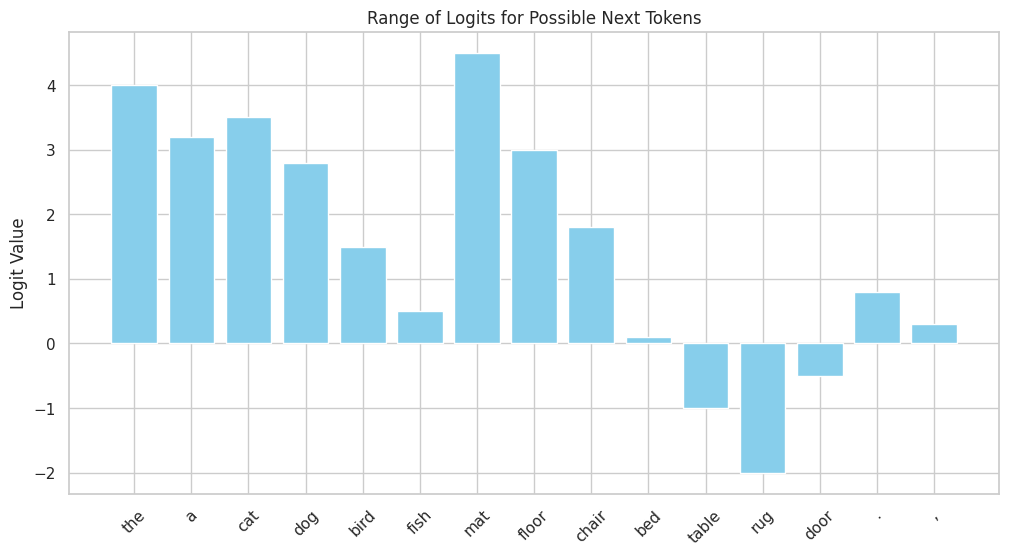

In [ ]:
# Simulate raw logits for our small vocabulary
# These are arbitrary values for demonstration, representing confidence scores
raw_logits = np.array([
    4.0,  # the
    3.2,  # a
    3.5,  # cat
    2.8,  # dog
    1.5,  # bird
    0.5,  # fish
    4.5,  # mat  <- Highest
    3.0,  # floor
    1.8,  # chair
    0.1,  # bed
    -1.0, # table
    -2.0, # rug
    -0.5, # door
    0.8,  # .
    0.3   # ,
])

print(f"--- 1. Logits ---")
print(f"Logits for the next token (shape: {raw_logits.shape}):")
for i, logit in enumerate(raw_logits):
    print(f"  {VOCAB[i]:<7}: {logit:.2f}")

# Plotting the range of logits
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(VOCAB, raw_logits, color='skyblue')
ax.set_ylabel("Logit Value")
ax.set_title("Range of Logits for Possible Next Tokens")
ax.tick_params(axis='x', rotation=45)
plt.show()

---

## 2. Applying Softmax

To convert logits into meaningful probability distributions (where all values are between 0 and 1 and sum up to 1), the **softmax** function is applied.

The softmax function for a vector of logits $z = [z_1, z_2, \ldots, z_N]$ is defined as:

$P(i) = \frac{e^{z_i}}{\sum_{j=1}^{N} e^{z_j}}$

where:
* $P(i)$ is the probability of the $i$-th token.
* $z_i$ is the logit for the $i$-th token.
* $N$ is the total number of tokens in the vocabulary.


--- 2. Softmax Application (Temperature = 1.0) ---
Probabilities after Softmax (sum: 1.0000):
  the    : 0.2126
  a      : 0.0955
  cat    : 0.1290
  dog    : 0.0640
  bird   : 0.0175
  fish   : 0.0064
  mat    : 0.3506
  floor  : 0.0782
  chair  : 0.0236
  bed    : 0.0043
  table  : 0.0014
  rug    : 0.0005
  door   : 0.0024
  .      : 0.0087
  ,      : 0.0053


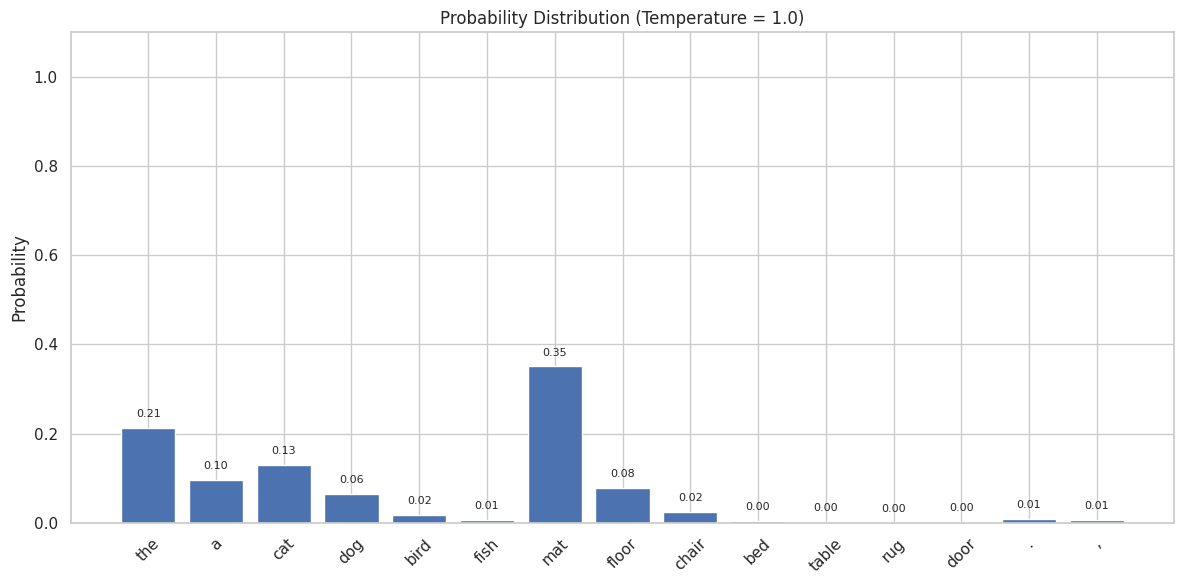

In [ ]:
print(f"\n--- 2. Softmax Application (Temperature = 1.0) ---")
probabilities_temp_1 = softmax(raw_logits, temperature=1.0)

print(f"Probabilities after Softmax (sum: {np.sum(probabilities_temp_1):.4f}):")
for i, prob in enumerate(probabilities_temp_1):
    print(f"  {VOCAB[i]:<7}: {prob:.4f}")

fig, ax = plt.subplots(figsize=(12, 6))
plot_distribution(probabilities_temp_1, VOCAB, "Probability Distribution (Temperature = 1.0)", ax)
plt.show()

---

## 3. Sampling Strategies (from the Softmax Distribution)

Once we have the probability distribution, we need a strategy to select the actual next token.

### 3a. Greedy Sampling

* **How it works:** Always selects the token with the highest probability. It's deterministic.
* **Pros:** Simple, always picks the "most confident" choice.
* **Cons:** Can lead to repetitive, generic, or stuck-in-a-loop outputs, as it doesn't explore other plausible options.


--- 3a. Greedy Sampling ---
Selected token (Greedy): 'mat' (Probability: 0.3506)


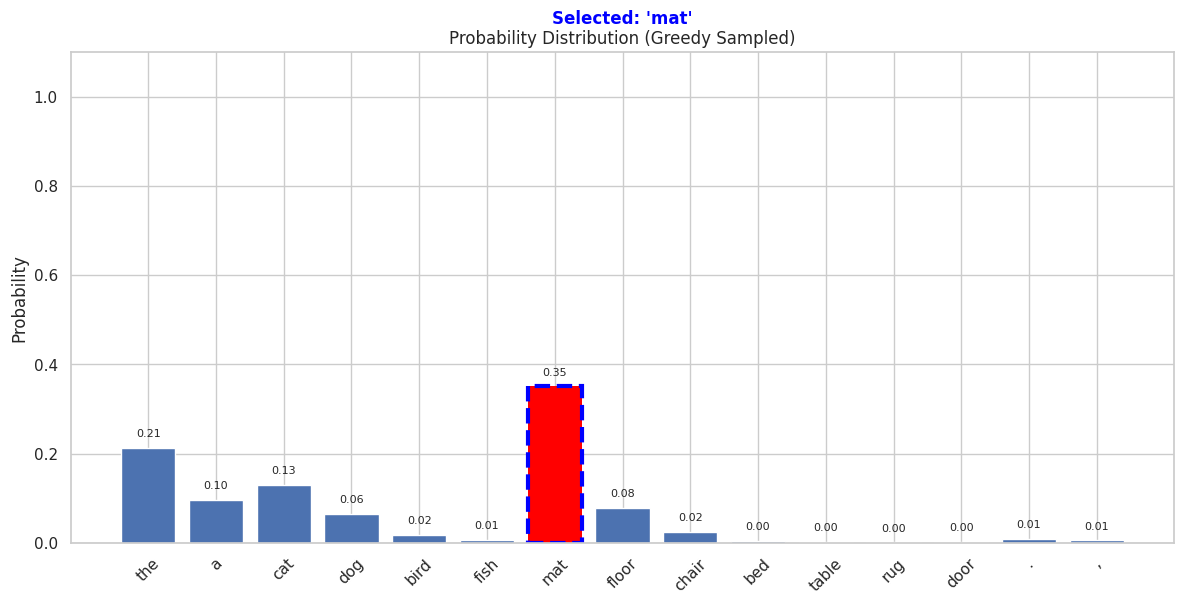

In [ ]:
print(f"\n--- 3a. Greedy Sampling ---")
greedy_token_idx = np.argmax(probabilities_temp_1)
greedy_token = VOCAB[greedy_token_idx]
print(f"Selected token (Greedy): '{greedy_token}' (Probability: {probabilities_temp_1[greedy_token_idx]:.4f})")

fig, ax = plt.subplots(figsize=(12, 6))
plot_distribution(probabilities_temp_1, VOCAB, "Probability Distribution (Greedy Sampled)", ax,
                  highlight_indices=[greedy_token_idx], sampled_token=greedy_token)
ax.text(0.5, 1.05, f"Selected: '{greedy_token}'", horizontalalignment='center',
         verticalalignment='bottom', transform=ax.transAxes, color='blue', fontsize=12, weight='bold')
plt.show()

### 3b. Top-P (Nucleus) Sampling

* **How it works:** Considers a dynamic subset of tokens. It sorts tokens by probability in descending order and selects the smallest set of tokens whose cumulative probability exceeds a threshold `p`. Then, it samples randomly from *only* these selected tokens, weighted by their probabilities.
* **Pros:** Adapts to the shape of the probability distribution. If there are a few very likely tokens, the nucleus will be small. If many tokens are equally likely, the nucleus will be larger. This helps maintain diversity without generating completely nonsensical tokens.
* **Parameter:** `top_p` (e.g., 0.9, 0.95).


#### 3b. Top-P (Nucleus) Sampling: Mathematical Example by Hand

Let's walk through a step-by-step mathematical calculation for Top-P (Nucleus) Sampling.

**How it works:**
Top-P sampling (also known as Nucleus Sampling) dynamically considers a subset of tokens whose cumulative probability exceeds a predefined threshold `p`. It sorts all possible next tokens by their probability in descending order. It then selects the smallest set of most probable tokens whose cumulative probability sum reaches or just exceeds the `p` threshold. Finally, it samples randomly from *only* these selected tokens, re-normalizing their probabilities to sum to 1 within this "nucleus".

**Scenario:**
Imagine our LLM has just processed a prompt and is predicting the **next token**. It outputs the following probabilities for a small hypothetical vocabulary:

| Token | Probability ($P(i)$) |
| :---- | :------------------- |
| A     | 0.40                 |
| B     | 0.30                 |
| C     | 0.15                 |
| D     | 0.10                 |
| E     | 0.05                 |

**Goal:** Apply Top-P sampling with a threshold of **$p = 0.75$** to select the next token.

---

#### **Step 1: Sort all tokens by probability in descending order.**

This is often already how the LLM's output logits are processed before softmax and sampling.

| Token | Original Probability | Rank |
| :---- | :------------------- | :--- |
| A     | 0.40                 | 1    |
| B     | 0.30                 | 2    |
| C     | 0.15                 | 3    |
| D     | 0.10                 | 4    |
| E     | 0.05                 | 5    |

---

#### **Step 2: Calculate the cumulative probability, adding tokens from highest to lowest probability, until the sum equals or exceeds $p=0.75$.**

This step defines our "nucleus". We sum probabilities until we cross the $p$ threshold. The token that causes the sum to cross the threshold is included.

| Token | Original Probability | Cumulative Probability | Exceeds $p=0.75$? | Include in Nucleus? |
| :---- | :------------------- | :--------------------- | :---------------- | :------------------ |
| A     | 0.40                 | 0.40                   | No                | Yes                 |
| B     | 0.30                 | $0.40 + 0.30 = 0.70$   | No                | Yes                 |
| C     | 0.15                 | $0.70 + 0.15 = 0.85$   | Yes               | Yes (this one crosses the threshold) |
| D     | 0.10                 | (Not considered for nucleus) |                   | No                  |
| E     | 0.05                 | (Not considered for nucleus) |                   | No                  |

**Resulting Nucleus:** Tokens {A, B, C}

**Explanation:**
* Adding A's probability (0.40) to the sum: Current sum = 0.40. (Still less than 0.75)
* Adding B's probability (0.30) to the sum: Current sum = $0.40 + 0.30 = 0.70$. (Still less than 0.75)
* Adding C's probability (0.15) to the sum: Current sum = $0.70 + 0.15 = 0.85$. **This now exceeds our threshold of 0.75.** Therefore, Token C is the last token included in our nucleus.
* Tokens D and E are excluded because their inclusion would push the cumulative sum even further beyond the threshold, and we only want the *smallest* set that meets the criteria.

---

#### **Step 3: Normalize the probabilities of the tokens *within the nucleus*.**

Now that we have our nucleus {A, B, C}, we treat their probabilities as a new mini-distribution. Their probabilities must be re-normalized so they sum to 1.

**Nucleus Tokens and their Original Probabilities:**

* A: 0.40
* B: 0.30
* C: 0.15

**Sum of Nucleus Probabilities:** $0.40 + 0.30 + 0.15 = 0.85$

**Normalized Probabilities for Sampling (inside the nucleus):**

* $P'(A) = \frac{0.40}{0.85} \approx 0.4706$
* $P'(B) = \frac{0.30}{0.85} \approx 0.3529$
* $P'(C) = \frac{0.15}{0.85} \approx 0.1765$

**Check:** $0.4706 + 0.3529 + 0.1765 = 1.0000$ (The sum is approximately 1 due to rounding).

---

#### **Step 4: Sample a token randomly from the normalized probabilities of the nucleus.**

At this final stage, you would perform a random draw based on these re-normalized probabilities:

* There's a $\approx 47.06\%$ chance of picking Token A.
* There's a $\approx 35.29\%$ chance of picking Token B.
* There's a $\approx 17.65\%$ chance of picking Token C.

Let's assume, after performing this random draw, the chosen token is **B**.

---

#### **Conclusion of this hand example:**

Using Top-P sampling with a threshold of $p=0.75$, the model selected **Token B**.

**Why this is effective:**
* If we had used **Greedy Sampling**, it would have always picked **A** (0.40), as it's the most probable.
* Top-P allowed B (and C) to still have a chance of being selected. This introduces desired diversity and creativity in the output, while still ensuring that only highly plausible tokens (those within the cumulative probability threshold) are considered. It adapts to the shape of the distribution: if only a few tokens are highly probable, the nucleus is small; if many are moderately probable, the nucleus is larger.


--- 3b. Top-P (Nucleus) Sampling ---
Top-P Threshold (p): 0.9
Tokens in Nucleus (highlighted red): ['mat', 'the', 'cat', 'a', 'floor', 'dog']
Selected token (Top-P Sampled): 'the' (Original Probability: 0.2126)


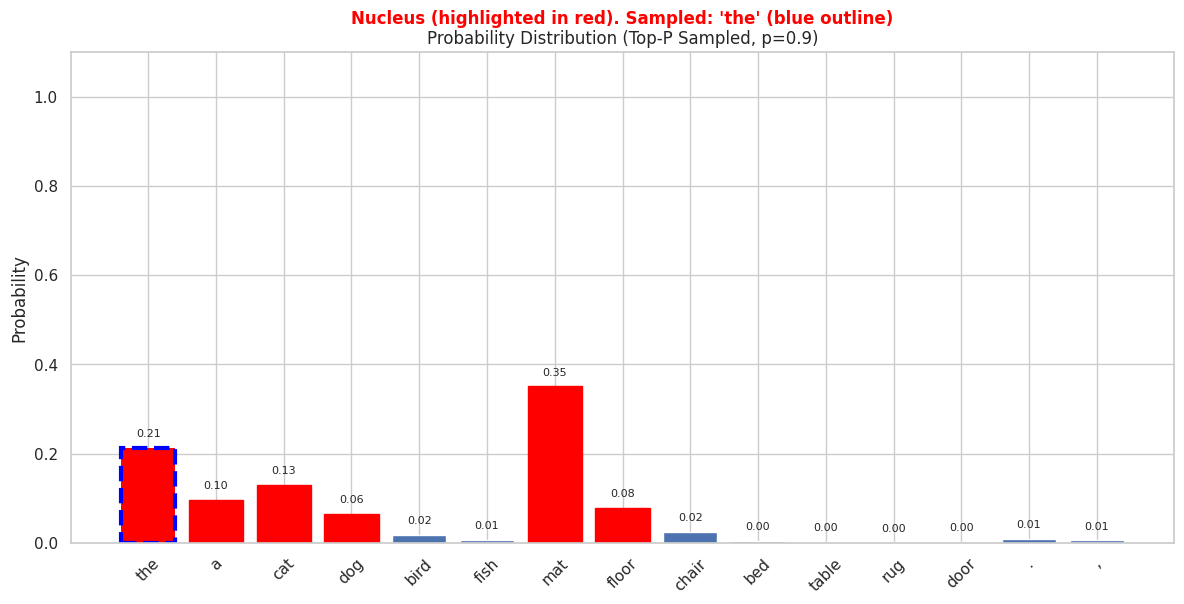

In [ ]:
print(f"\n--- 3b. Top-P (Nucleus) Sampling ---")
top_p_threshold = 0.9

# Sort probabilities and get original indices
sorted_indices = np.argsort(probabilities_temp_1)[::-1] # Descending order
sorted_probs = probabilities_temp_1[sorted_indices]

cumulative_probs = np.cumsum(sorted_probs)

# Select tokens for the nucleus
# Hugging Face's implementation detail: includes the token that pushes cumulative_probs over top_p
nucleus_indices_sorted = sorted_indices[cumulative_probs <= top_p_threshold]
if len(nucleus_indices_sorted) < len(sorted_indices) and (len(nucleus_indices_sorted) == 0 or cumulative_probs[len(nucleus_indices_sorted) - 1] < top_p_threshold):
    nucleus_indices_sorted = sorted_indices[:len(nucleus_indices_sorted) + 1]


print(f"Top-P Threshold (p): {top_p_threshold}")
print(f"Tokens in Nucleus (highlighted red): {[VOCAB[i] for i in nucleus_indices_sorted]}")

# Normalize probabilities within the nucleus for sampling
nucleus_probs = probabilities_temp_1[nucleus_indices_sorted]
if np.sum(nucleus_probs) == 0:
    print("Warning: Nucleus is empty, cannot sample.")
    top_p_token = "N/A"
    top_p_token_idx = -1
else:
    normalized_nucleus_probs = nucleus_probs / np.sum(nucleus_probs)
    chosen_idx_in_nucleus = np.random.choice(len(nucleus_indices_sorted), p=normalized_nucleus_probs)
    top_p_token_idx = nucleus_indices_sorted[chosen_idx_in_nucleus]
    top_p_token = VOCAB[top_p_token_idx]

print(f"Selected token (Top-P Sampled): '{top_p_token}' (Original Probability: {probabilities_temp_1[top_p_token_idx]:.4f})")

fig, ax = plt.subplots(figsize=(12, 6))
plot_distribution(probabilities_temp_1, VOCAB,
                  f"Probability Distribution (Top-P Sampled, p={top_p_threshold})", ax,
                  highlight_indices=nucleus_indices_sorted, sampled_token=top_p_token) # Highlight all in nucleus
ax.text(0.5, 1.05, f"Nucleus (highlighted in red). Sampled: '{top_p_token}' (blue outline)", horizontalalignment='center',
         verticalalignment='bottom', transform=ax.transAxes, color='red', fontsize=12, weight='bold')
plt.show()

---

## 4. Scaling the Distribution using Temperature

**Temperature** is a parameter applied *before* softmax, directly influencing the distribution of probabilities. It scales the logits:

$P(i) = \frac{e^{z_i / \text{temperature}}}{\sum_{j=1}^{N} e^{z_j / \text{temperature}}}$

where:
* **Temperature > 1.0 (Higher):** Makes the distribution *flatter*. It increases the probability of less likely tokens and decreases the probability of highly likely ones. This leads to more diverse, creative, but potentially less coherent output.
* **Temperature < 1.0 (Lower):** Makes the distribution *sharper*. It increases the probability of highly likely tokens and decreases the probability of less likely ones. This leads to more conservative, predictable, and often more coherent output.
* **Temperature = 1.0:** No change to the original logit distribution before softmax.
* **Temperature $\rightarrow$ 0:** As temperature approaches zero, the probability of the most likely token approaches 1, and all others approach 0. This effectively makes sampling behave like greedy decoding.


--- 4. Scaling Distribution with Temperature ---

Probabilities with Temperature = 0.2:
  the    : 0.0752
  a      : 0.0014
  cat    : 0.0062
  dog    : 0.0002
  bird   : 0.0000
  fish   : 0.0000
  mat    : 0.9165
  floor  : 0.0005
  chair  : 0.0000
  bed    : 0.0000
  table  : 0.0000
  rug    : 0.0000
  door   : 0.0000
  .      : 0.0000
  ,      : 0.0000

Probabilities with Temperature = 2.0:
  the    : 0.1558
  a      : 0.1044
  cat    : 0.1213
  dog    : 0.0855
  bird   : 0.0446
  fish   : 0.0271
  mat    : 0.2000
  floor  : 0.0945
  chair  : 0.0518
  bed    : 0.0222
  table  : 0.0128
  rug    : 0.0078
  door   : 0.0164
  .      : 0.0314
  ,      : 0.0245


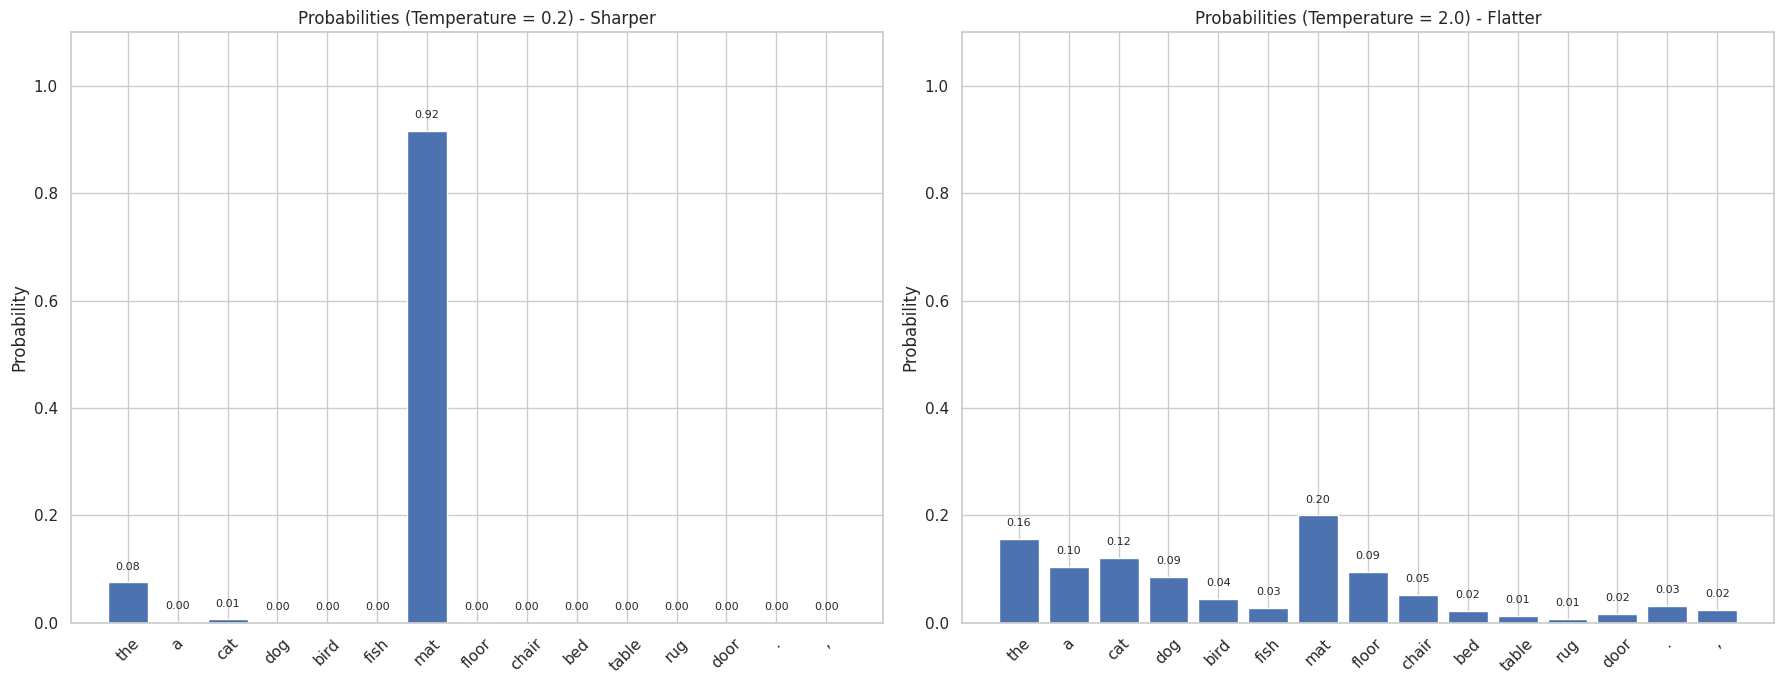

In [ ]:
print(f"\n--- 4. Scaling Distribution with Temperature ---")

# Let's try a low temperature
low_temp = 0.2
probabilities_low_temp = softmax(raw_logits, temperature=low_temp)
print(f"\nProbabilities with Temperature = {low_temp}:")
for i, prob in enumerate(probabilities_low_temp):
    print(f"  {VOCAB[i]:<7}: {prob:.4f}")

# Let's try a high temperature
high_temp = 2.0
probabilities_high_temp = softmax(raw_logits, temperature=high_temp)
print(f"\nProbabilities with Temperature = {high_temp}:")
for i, prob in enumerate(probabilities_high_temp):
    print(f"  {VOCAB[i]:<7}: {prob:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_distribution(probabilities_low_temp, VOCAB, f"Probabilities (Temperature = {low_temp}) - Sharper", axes[0])
plot_distribution(probabilities_high_temp, VOCAB, f"Probabilities (Temperature = {high_temp}) - Flatter", axes[1])
plt.show()

---

## 5. Greedy and Top-P at Different Temperatures

Now, let's observe how the sampling behavior changes when temperature is applied *before* the sampling strategy.

### 5a. Greedy Sampling at Different Temperatures

Greedy sampling is conceptually unaffected by temperature *unless* temperature is exactly 0 (which collapses all probability to the max). When `do_sample=True` and `temperature` is used, if `top_k` and `top_p` are not specified, it will sample from the *entire* (temperature-scaled) distribution. If `temperature` is very low, it will resemble greedy.


--- 5a. Greedy Sampling at Different Temperatures ---
Greedy with Temp 0.2: 'mat' (Prob: 0.9165)
Greedy with Temp 2.0: 'mat' (Prob: 0.2000)


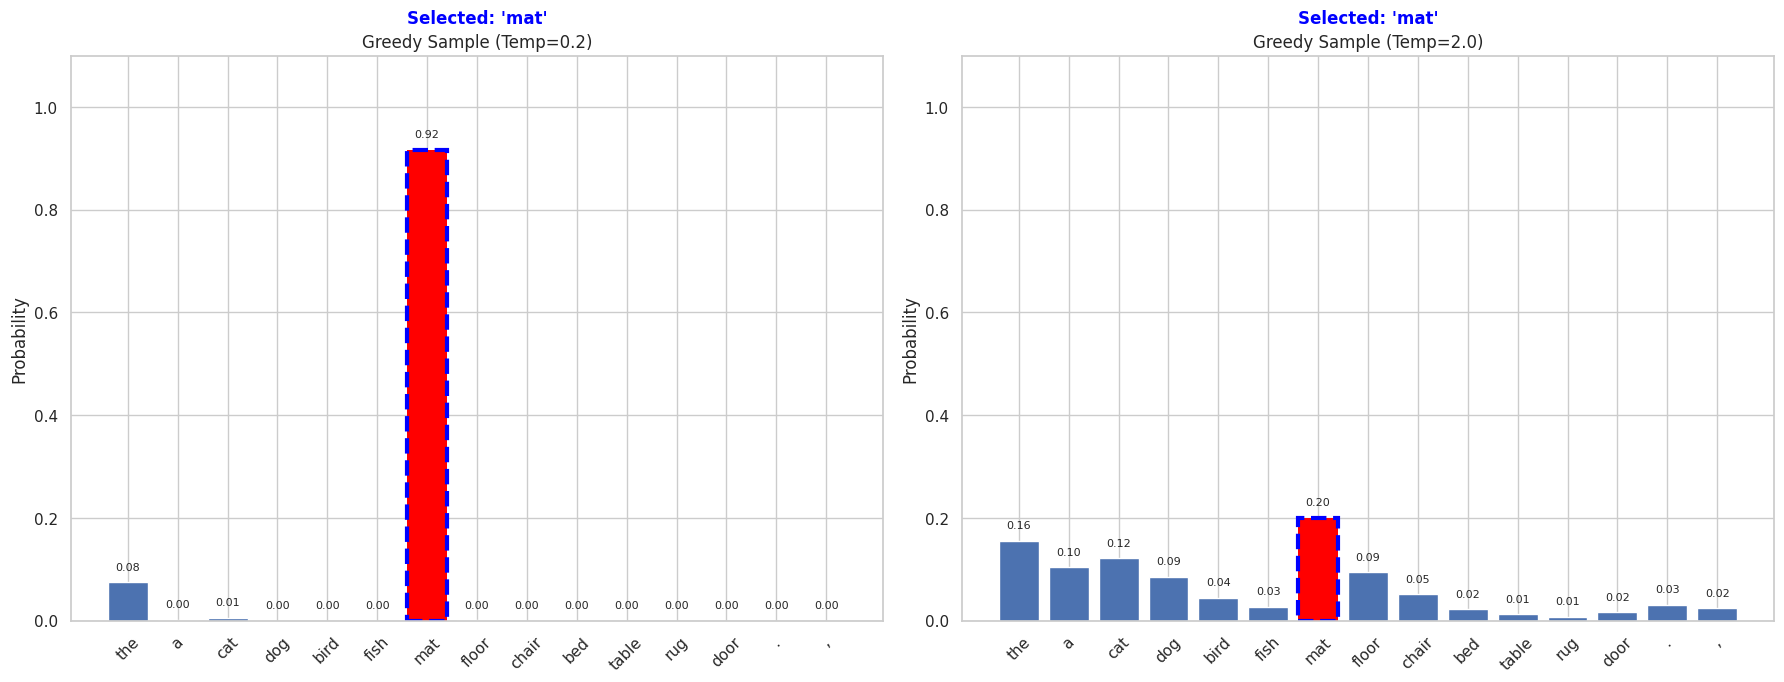

In [ ]:
print(f"\n--- 5a. Greedy Sampling at Different Temperatures ---")

# At low temp, the max probability becomes even more dominant
greedy_low_temp_idx = np.argmax(probabilities_low_temp)
greedy_low_temp_token = VOCAB[greedy_low_temp_idx]
print(f"Greedy with Temp {low_temp}: '{greedy_low_temp_token}' (Prob: {probabilities_low_temp[greedy_low_temp_idx]:.4f})")

# At high temp, the max probability is still the max, but less dominant
greedy_high_temp_idx = np.argmax(probabilities_high_temp)
greedy_high_temp_token = VOCAB[greedy_high_temp_idx]
print(f"Greedy with Temp {high_temp}: '{greedy_high_temp_token}' (Prob: {probabilities_high_temp[greedy_high_temp_idx]:.4f})")


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_distribution(probabilities_low_temp, VOCAB,
                  f"Greedy Sample (Temp={low_temp})", axes[0],
                  highlight_indices=[greedy_low_temp_idx], sampled_token=greedy_low_temp_token)
axes[0].text(0.5, 1.05, f"Selected: '{greedy_low_temp_token}'", horizontalalignment='center',
             verticalalignment='bottom', transform=axes[0].transAxes, color='blue', fontsize=12, weight='bold')

plot_distribution(probabilities_high_temp, VOCAB,
                  f"Greedy Sample (Temp={high_temp})", axes[1],
                  highlight_indices=[greedy_high_temp_idx], sampled_token=greedy_high_temp_token)
axes[1].text(0.5, 1.05, f"Selected: '{greedy_high_temp_token}'", horizontalalignment='center',
             verticalalignment='bottom', transform=axes[1].transAxes, color='blue', fontsize=12, weight='bold')
plt.show()

### 5b. Top-P Sampling at Different Temperatures

This is where temperature truly shines in combination with sampling strategies.

* **Low Temperature + Top-P:** The distribution is sharper, so the nucleus (the set of tokens whose cumulative probability sums to `p`) will likely be *smaller*, consisting of fewer, very high-probability tokens. This leads to more focused but still slightly diverse sampling.
* **High Temperature + Top-P:** The distribution is flatter, so the nucleus will likely be *larger*, encompassing more tokens with more spread-out probabilities. This allows for more diverse and creative sampling, as the LLM considers a broader range of plausible next tokens.


--- 5b. Top-P Sampling at Different Temperatures ---

Top-P (p=0.9) with Temp=0.2:
  Nucleus tokens: ['mat']
  Selected: 'mat' (Original Prob: 0.9165)

Top-P (p=0.9) with Temp=2.0:
  Nucleus tokens: ['mat', 'the', 'cat', 'a', 'floor', 'dog', 'chair', 'bird', '.', 'fish']
  Selected: '.' (Original Prob: 0.0314)


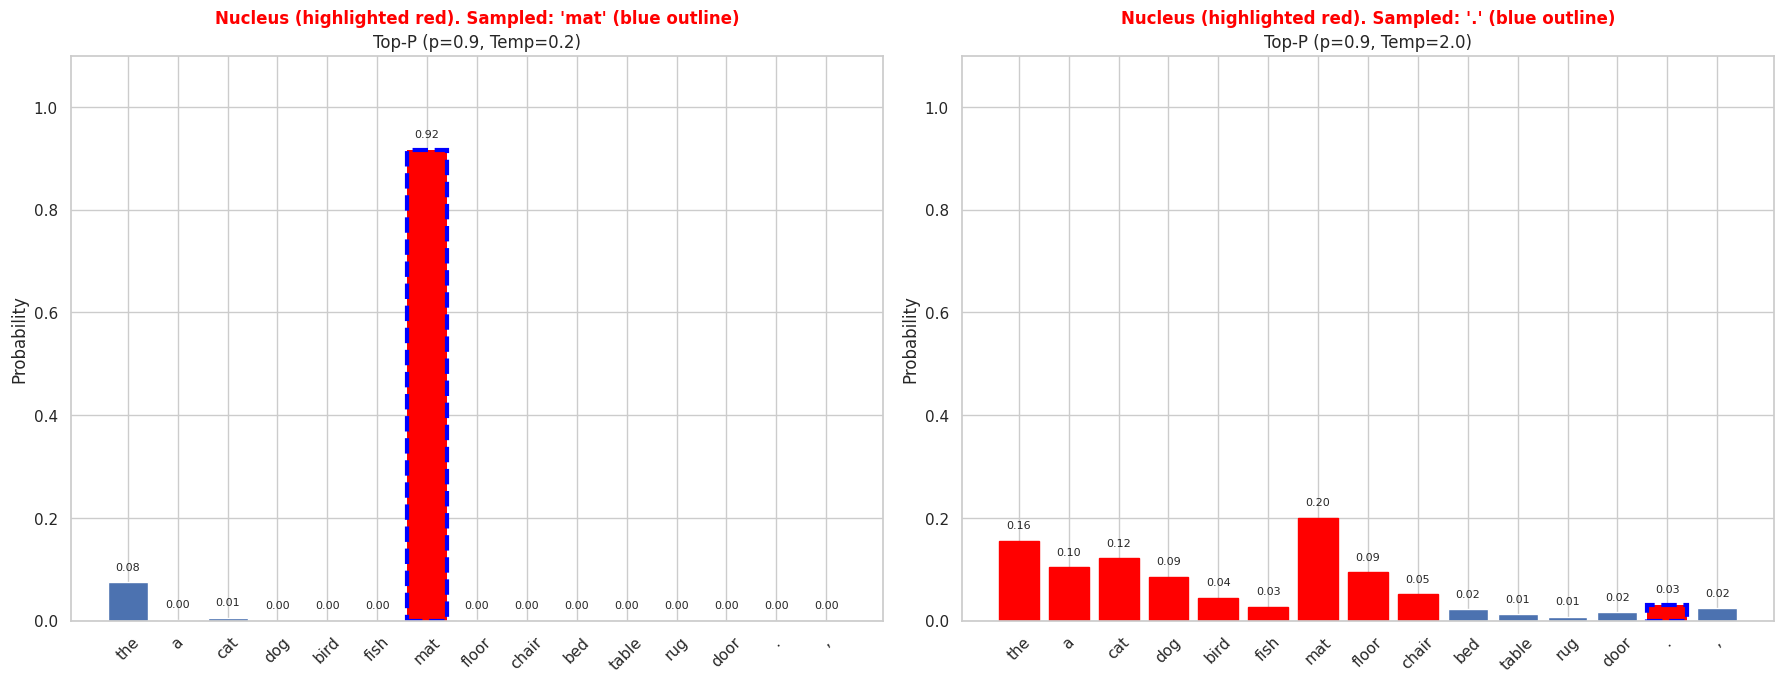

In [ ]:
print(f"\n--- 5b. Top-P Sampling at Different Temperatures ---")
top_p_threshold = 0.9

def perform_top_p_sampling(probabilities, temp_value, threshold, vocab):
    """Helper to perform and explain top-p sampling for a given probability distribution."""
    sorted_indices = np.argsort(probabilities)[::-1]
    sorted_probs = probabilities[sorted_indices]

    cumulative_probs = np.cumsum(sorted_probs)
    nucleus_indices_sorted = sorted_indices[cumulative_probs <= threshold]
    if len(nucleus_indices_sorted) < len(sorted_indices) and (len(nucleus_indices_sorted) == 0 or cumulative_probs[len(nucleus_indices_sorted) - 1] < threshold):
        nucleus_indices_sorted = sorted_indices[:len(nucleus_indices_sorted) + 1]

    nucleus_probs = probabilities[nucleus_indices_sorted]
    if np.sum(nucleus_probs) == 0: # Handle edge case where no tokens are selected
        return None, None, []

    normalized_nucleus_probs = nucleus_probs / np.sum(nucleus_probs)
    chosen_idx_in_nucleus = np.random.choice(len(nucleus_indices_sorted), p=normalized_nucleus_probs)
    chosen_token_idx = nucleus_indices_sorted[chosen_idx_in_nucleus]
    chosen_token = vocab[chosen_token_idx]

    return chosen_token, chosen_token_idx, nucleus_indices_sorted

# Top-P with Low Temperature
chosen_low_temp, chosen_low_temp_idx, nucleus_low_temp_indices = \
    perform_top_p_sampling(probabilities_low_temp, low_temp, top_p_threshold, VOCAB)
print(f"\nTop-P (p={top_p_threshold}) with Temp={low_temp}:")
print(f"  Nucleus tokens: {[VOCAB[i] for i in nucleus_low_temp_indices]}")
if chosen_low_temp:
    print(f"  Selected: '{chosen_low_temp}' (Original Prob: {probabilities_low_temp[chosen_low_temp_idx]:.4f})")

# Top-P with High Temperature
chosen_high_temp, chosen_high_temp_idx, nucleus_high_temp_indices = \
    perform_top_p_sampling(probabilities_high_temp, high_temp, top_p_threshold, VOCAB)
print(f"\nTop-P (p={top_p_threshold}) with Temp={high_temp}:")
print(f"  Nucleus tokens: {[VOCAB[i] for i in nucleus_high_temp_indices]}")
if chosen_high_temp:
    print(f"  Selected: '{chosen_high_temp}' (Original Prob: {probabilities_high_temp[chosen_high_temp_idx]:.4f})")


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plot_distribution(probabilities_low_temp, VOCAB,
                  f"Top-P (p={top_p_threshold}, Temp={low_temp})", axes[0],
                  highlight_indices=nucleus_low_temp_indices, sampled_token=chosen_low_temp)
if chosen_low_temp:
    axes[0].text(0.5, 1.05, f"Nucleus (highlighted red). Sampled: '{chosen_low_temp}' (blue outline)", horizontalalignment='center',
                 verticalalignment='bottom', transform=axes[0].transAxes, color='red', fontsize=12, weight='bold')


plot_distribution(probabilities_high_temp, VOCAB,
                  f"Top-P (p={top_p_threshold}, Temp={high_temp})", axes[1],
                  highlight_indices=nucleus_high_temp_indices, sampled_token=chosen_high_temp)
if chosen_high_temp:
    axes[1].text(0.5, 1.05, f"Nucleus (highlighted red). Sampled: '{chosen_high_temp}' (blue outline)", horizontalalignment='center',
                 verticalalignment='bottom', transform=axes[1].transAxes, color='red', fontsize=12, weight='bold')
plt.show()

---

## 6. Autoregressive Process Walkthrough (Conceptual)

This section conceptually demonstrates the iterative, token-by-token nature of LLM generation. Each new token is predicted based on the entire sequence generated so far.

In [ ]:
def simulate_llm_autoregressive_process(initial_prompt, max_tokens=5, vocab_list=VOCAB):
    """
    Simulates the autoregressive process of an LLM, generating one token at a time.
    Uses simplified transitions for demonstration.

    Args:
        initial_prompt (str): The starting text for the generation.
        max_tokens (int): The maximum number of tokens to generate.
    """
    print("--- Autoregressive Process Simulation ---")
    current_sequence = initial_prompt.split()

    print(f"Initial Prompt: '{' '.join(current_sequence)}'\n")
    print("Starting generation...\n")

    # Simple dictionary to simulate next token probabilities (conceptual)
    # In a real LLM, these would be complex probabilities from the model
    simplified_next_token_rules = {
        "the": ["cat", "dog", "mat", "floor", "door"],
        "cat": ["sat", "jumped", "slept"],
        "dog": ["barked", "wagged", "chased"],
        "sat": ["on", "beside"],
        "on": ["the", "a"],
        "mat": [".", ","],
        "floor": [".", ","],
        "jumped": ["over", "through"],
        "barked": ["loudly", "at"],
        "slept": ["soundly", "peacefully"],
        ".": ["The", "It", "And"], # Simulate sentence breaks
        ",": ["and", "but", "so"],
    }

    for i in range(max_tokens):
        print(f"\n{'='*20} Step {i + 1} {'='*20}")
        print(f"  Current sequence (input to LLM): '{' '.join(current_sequence)}'")

        # --- LLM's "Thinking" Phase (Simulated) ---
        print("  LLM is calculating probabilities for the next token based on this sequence...")
        time.sleep(1) # Simulate processing time

        last_token = current_sequence[-1].lower().replace('.', '').replace(',', '') # Clean last token for rule lookup

        # Simulate logits for the next token based on the last token and simple rules
        simulated_logits = np.random.rand(VOCAB_SIZE) * 2 - 1 # Base random logits
        if last_token in simplified_next_token_rules:
            # Boost logits for likely next tokens based on our simple rules
            for possible_token in simplified_next_token_rules[last_token]:
                if possible_token in vocab_list:
                    idx = vocab_list.index(possible_token)
                    simulated_logits[idx] += 3.0 # Increase confidence for rule-based next tokens

        # Apply softmax to get probabilities (simulating LLM output)
        probabilities = softmax(simulated_logits, temperature=0.7) # Using a moderate temperature for this simulation

        # Simulate selecting a token using a basic sampling (e.g., random choice from top-P)
        # For simplicity, we'll just pick the highest probability token for demonstration
        next_token_idx = np.argmax(probabilities) # Simplistic choice
        # You could uncomment the lines below to use Top-P for this simulation step
        # sorted_indices = np.argsort(probabilities)[::-1]
        # sorted_probs = probabilities[sorted_indices]
        # cumulative_probs = np.cumsum(sorted_probs)
        # nucleus_indices_sorted = sorted_indices[cumulative_probs <= 0.9] # Top-P 0.9
        # if len(nucleus_indices_sorted) < len(sorted_indices) and (len(nucleus_indices_sorted) == 0 or cumulative_probs[len(nucleus_indices_sorted) - 1] < 0.9):
        #     nucleus_indices_sorted = sorted_indices[:len(nucleus_indices_sorted) + 1]
        # if len(nucleus_indices_sorted) > 0:
        #     normalized_nucleus_probs = probabilities[nucleus_indices_sorted] / np.sum(probabilities[nucleus_indices_sorted])
        #     next_token_idx = nucleus_indices_sorted[np.random.choice(len(nucleus_indices_sorted), p=normalized_nucleus_probs)]
        # else:
        #     next_token_idx = np.argmax(probabilities) # Fallback to greedy if nucleus is empty

        next_token = vocab_list[next_token_idx]

        print(f"  LLM predicts the next token based on the sequence ending with '{current_sequence[-1]}'.")
        print(f"  Selected next token: '{next_token}'")

        # --- Autoregressive Step ---
        current_sequence.append(next_token) # Add the new token to the sequence
        print(f"  New sequence: '{' '.join(current_sequence)}'\n")

        # Optional: Stop if an end-of-sequence token is "generated"
        if next_token == ".":
             print("End of sequence token generated. Stopping.")
             break

        time.sleep(0.8) # Pause for readability

    print("--- Generation Complete ---")
    print(f"Final Generated Text: '{' '.join(current_sequence)}'")

# Let's run the autoregressive simulation
print("\n" + "="*70)
simulate_llm_autoregressive_process(initial_prompt="The cat sat on the", max_tokens=4)
print("\n" + "="*70)
simulate_llm_autoregressive_process(initial_prompt="A dog barked", max_tokens=3)


--- Autoregressive Process Simulation ---
Initial Prompt: 'The cat sat on the'

Starting generation...


==================== Step 1 ====================
  Current sequence (input to LLM): 'The cat sat on the'
  LLM is calculating probabilities for the next token based on this sequence...
  LLM predicts the next token based on the sequence ending with 'the'.
  Selected next token: 'door'
  New sequence: 'The cat sat on the door'


==================== Step 2 ====================
  Current sequence (input to LLM): 'The cat sat on the door'
  LLM is calculating probabilities for the next token based on this sequence...
  LLM predicts the next token based on the sequence ending with 'door'.
  Selected next token: 'rug'
  New sequence: 'The cat sat on the door rug'


==================== Step 3 ====================
  Current sequence (input to LLM): 'The cat sat on the door rug'
  LLM is calculating probabilities for the next token based on this sequence...
  LLM predicts the next token b